# Main Experiment Justice Principles: Descriptive Statistics & Visuals


This notebook analyzes Main Experiment run logs to produce descriptive statistics and publication-ready figures for the justice-principles experiment.


In [ ]:
import sys
import json
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

_NOTEBOOK_DIR = Path.cwd().resolve()
for candidate in [_NOTEBOOK_DIR, *_NOTEBOOK_DIR.parents]:
    if (candidate / "experiment_execution").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

# Style and visualization
from experiment_execution.utils_experiment_execution import (
    COLORS,
    FIG_SIZES,
    FONT_SIZES,
    PRINCIPLE_COLORS,
    PRINCIPLE_DISPLAY_NAMES,
    apply_theme,
    format_principle_label,
    format_principle_labels,
)

# Constants
from experiment_execution.utils_experiment_execution import (
    CERTAINTY_TO_SCORE,
    FINAL_WAVE,
    PRINCIPLE_LABELS,
    PRINCIPLE_ORDER,
    WAVE_DEFINITIONS,
    WAVE_ORDER,
)

# Data loading
from experiment_execution.utils_experiment_execution import (
    load_experiment_runs,
    extract_run_metrics,
    extract_vote_rounds,
    extract_rankings,
    extract_income_classes,
    build_transition_data,
    create_transition_matrix,
    create_preference_ordering_table,
    prepare_switcher_analysis,
    summarize_income_preferences,
)

# Visualization functions
from experiment_execution.utils_experiment_execution import (
    plot_floor_constraint_distribution,
    plot_rounds_to_outcome,
    plot_preference_stability,
    plot_transition_heatmaps,
    plot_long_term_stability,
    plot_long_term_margin,
    plot_income_preference_bars,
    plot_income_composition,
)

apply_theme()

In [2]:
def locate_project_root(markers: Tuple[str, ...] = ("experiment_execution", "config")) -> Path:
    """Find the project root by looking for known directories."""
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError("Could not locate project root from current working directory.")


PROJECT_ROOT = locate_project_root()
DATA_DIR = PROJECT_ROOT / "experiment_execution" / "main_experiment" / "results"
TERMINAL_DIR = PROJECT_ROOT / "experiment_execution" / "main_experiment" / "terminal_outputs"


In [3]:
# Load all Main Experiment runs
runs = load_experiment_runs(
    results_dir=DATA_DIR,
    pattern="main_experiment_condition_*_config_results.json",
    terminal_outputs_dir=TERMINAL_DIR,
    log_pattern="main_experiment_condition_*_log",
)

# Extract structured data
run_metrics_records = [extract_run_metrics(run_id, run_data) for run_id, run_data in runs]
vote_round_records = []
top_choice_records = []
long_ranking_records = []

for run_id, run_data in runs:
    vote_round_records.extend(extract_vote_rounds(run_id, run_data))
    top_rows, long_rows = extract_rankings(run_id, run_data)
    top_choice_records.extend(top_rows)
    long_ranking_records.extend(long_rows)

run_metrics = pd.DataFrame(run_metrics_records)
vote_rounds = pd.DataFrame(vote_round_records)
ranking_long = pd.DataFrame(long_ranking_records)
ranking_top = pd.DataFrame(top_choice_records)

ranking_top["wave_label"] = pd.Categorical(ranking_top["wave_label"], categories=WAVE_ORDER, ordered=True)
ranking_long["wave_label"] = pd.Categorical(ranking_long["wave_label"], categories=WAVE_ORDER, ordered=True)

print(f"Loaded {len(runs)} result files.")
run_metrics.head()


Loaded 33 result files.


,run_id,consensus_reached,consensus_principle,rounds_to_outcome,max_rounds,total_vote_attempts,successful_votes,total_vote_rounds
0,main_experiment_condition_10_config_results,True,Max Avg + Floor,8,10,1,1,1
1,main_experiment_condition_11_config_results,True,Max Avg + Floor,4,10,1,1,1
2,main_experiment_condition_12_config_results,True,Max Avg + Floor,7,10,1,1,1
3,main_experiment_condition_13_config_results,True,Max Avg + Floor,6,10,1,1,1
4,main_experiment_condition_14_config_results,True,Max Avg + Floor,4,10,1,1,1


## Data Summary

In [4]:

num_runs = run_metrics.shape[0]
unique_agents = ranking_top[["run_id", "agent"]].drop_duplicates().shape[0]
num_waves = ranking_top["wave_label"].nunique()
consensus_runs = run_metrics[run_metrics["consensus_reached"] == True].shape[0]

summary_df = pd.DataFrame(
    {
        "Metric": ["Runs", "Consensus runs", "Agent sessions", "Preference waves"],
        "Value": [num_runs, consensus_runs, unique_agents, num_waves]
    }
)

display(summary_df)

expected_agents = unique_agents
coverage = (ranking_top.drop_duplicates(subset=["run_id", "agent", "wave_label"])
                     .groupby("wave_label")
                     .size()
                     .reindex(WAVE_ORDER, fill_value=0))
missing = expected_agents - coverage
coverage_table = pd.DataFrame({"Responses": coverage, "Missing": missing})
display(coverage_table)


,Metric,Value
0,Runs,33
1,Consensus runs,30
2,Agent sessions,165
3,Preference waves,4


/var/folders/wf/_h59fnv53s7476fhw5sn5smh0000gn/T/ipykernel_26234/1307473778.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("wave_label")


,Responses,Missing
wave_label,,
Wave 1 - Initial,165,0
Wave 2 - Post-Explanation,165,0
Wave 3 - Final Phase 1,165,0
Wave 4 - Post-Group,165,0


## Preference Orderings by Wave

Below are frequency tables showing how many agents reported each complete ranking of the four justice principles at each measurement wave. Orderings are shown from most to least popular.

In [ ]:
# Use centralized function to generate preference ordering tables

# Generate tables for all four waves
print("=" * 100)
print("WAVE 1 - INITIAL (After Principle Introduction)")
print("=" * 100)
wave1_table = create_preference_ordering_table(ranking_long, "Wave 1 - Initial")
display(wave1_table)

print("\n" + "=" * 100)
print("WAVE 2 - POST-EXPLANATION (After Detailed Explanation)")
print("=" * 100)
wave2_table = create_preference_ordering_table(ranking_long, "Wave 2 - Post-Explanation")
display(wave2_table)

print("\n" + "=" * 100)
print("WAVE 3 - FINAL PHASE 1 (End of Individual Deliberation)")
print("=" * 100)
wave3_table = create_preference_ordering_table(ranking_long, "Wave 3 - Final Phase 1")
display(wave3_table)

print("\n" + "=" * 100)
print("WAVE 4 - POST-GROUP (After Group Discussion)")
print("=" * 100)
wave4_table = create_preference_ordering_table(ranking_long, "Wave 4 - Post-Group")
display(wave4_table)

# Summary statistics across waves
print("\n" + "=" * 100)
print("SUMMARY: Unique Orderings Per Wave")
print("=" * 100)
summary_data = []
for wave in WAVE_ORDER:
    wave_data = ranking_long[ranking_long["wave_label"] == wave]
    if not wave_data.empty:
        orderings = []
        for (run_id, agent), group in wave_data.groupby(["run_id", "agent"]):
            sorted_group = group.sort_values("rank")
            ordering = tuple(sorted_group["principle_label"].tolist())
            orderings.append(ordering)
        unique_count = len(set(orderings))
        total_count = len(orderings)
        summary_data.append({
            "Wave": wave,
            "Total Responses": total_count,
            "Unique Orderings": unique_count,
            "Diversity Ratio": f"{unique_count}/{total_count} ({unique_count/total_count*100:.1f}%)"
        })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

## Rounds to Outcome

## Floor Constraint Amounts

In [ ]:
# Use centralized visualization function
plot_floor_constraint_distribution(
    vote_rounds,
    title_suffix="Main Experiment"
)

## Voting Attempts and Success Rate

In [ ]:
# Use centralized visualization function
plot_rounds_to_outcome(
    run_metrics,
    title_suffix="Main Experiment"
)

## Preference Evolution and Transitions

The following visualizations track how agents' top-choice preferences change across the four measurement waves, revealing patterns of stability, switching, and long-term loyalty.

In [8]:
# Build transition data using centralized function
transition_data = build_transition_data(ranking_top)
print(f"Built transition data for {len(transition_data)} agents")
print(f"\nSample transitions:")
display(transition_data.head(10))


Built transition data for 165 agents

Sample transitions:


,run_id,agent,wave1,wave2,wave3,wave4
0,main_experiment_condition_10_config_results,Agent_1,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Floor
1,main_experiment_condition_10_config_results,Agent_2,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor
2,main_experiment_condition_10_config_results,Agent_3,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor
3,main_experiment_condition_10_config_results,Agent_4,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor
4,main_experiment_condition_10_config_results,Agent_5,Max Avg + Floor,Max Avg + Floor,Max Floor,Max Floor
5,main_experiment_condition_11_config_results,Agent_1,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor
6,main_experiment_condition_11_config_results,Agent_2,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor
7,main_experiment_condition_11_config_results,Agent_3,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor
8,main_experiment_condition_11_config_results,Agent_4,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor
9,main_experiment_condition_11_config_results,Agent_5,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor


In [ ]:
# Use centralized visualization function
plot_preference_stability(
    transition_data,
    title_suffix="Main Experiment"
)

In [ ]:
# Use centralized visualization function
principle_display_order = format_principle_labels(PRINCIPLE_ORDER)

plot_transition_heatmaps(
    transition_data,
    principle_display_order=principle_display_order,
    format_principle_label=format_principle_label,
    title_suffix="Main Experiment"
)

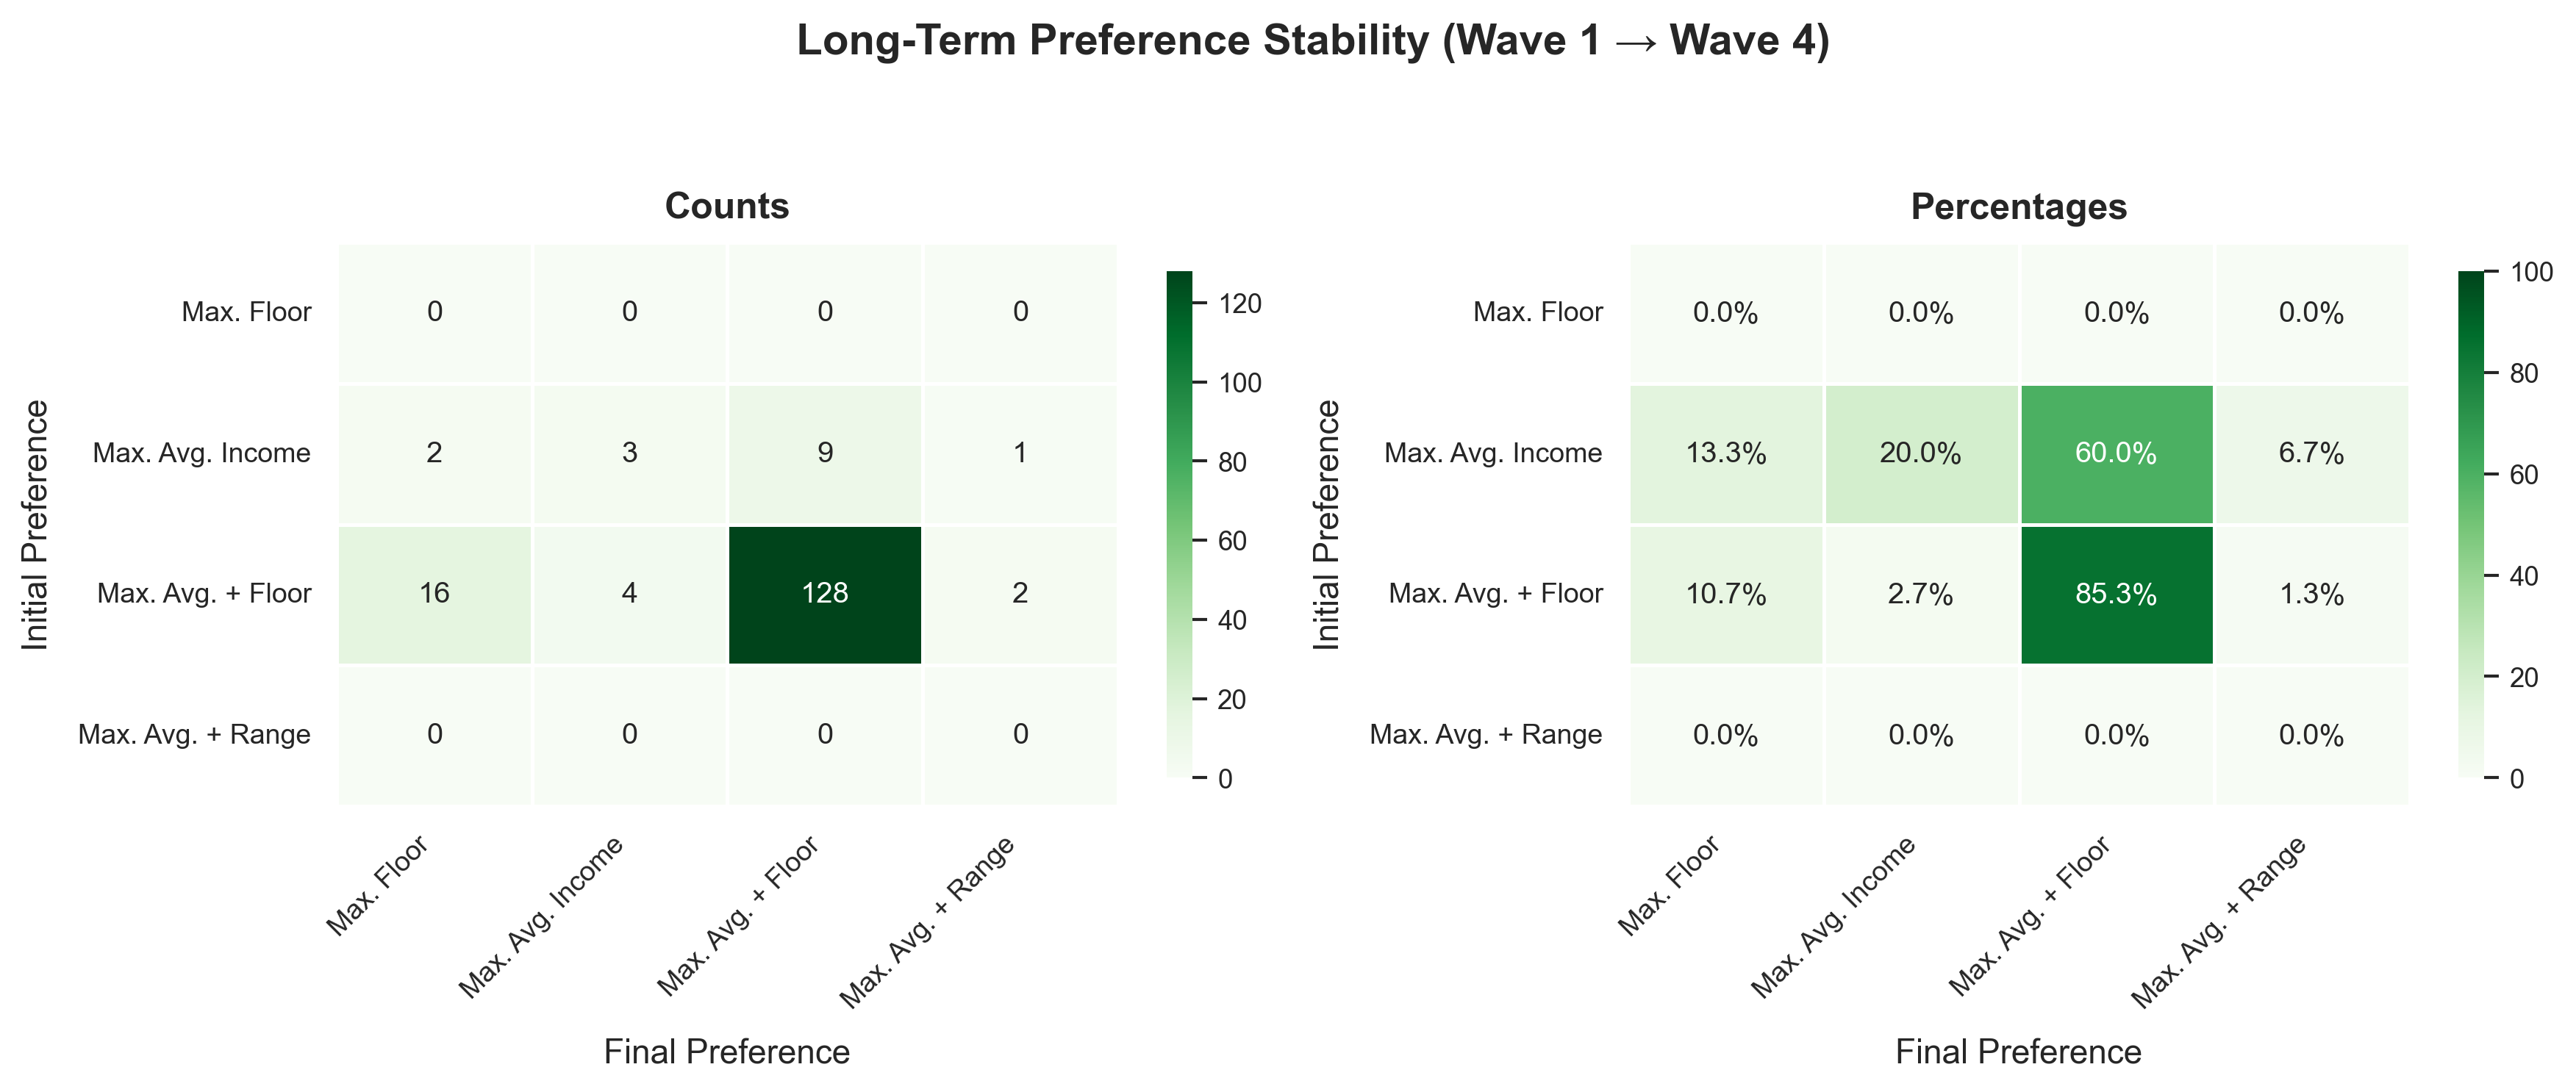

Long-Term Stability (Wave 1 → Wave 4) [Main Experiment]
Max. Floor               :   0/  0 maintained (  0.0%)
Max. Avg. Income         :   3/ 15 maintained ( 20.0%)
Max. Avg. + Floor        : 128/150 maintained ( 85.3%)
Max. Avg. + Range        :   0/  0 maintained (  0.0%)
OVERALL                  : 131/165 agents ( 79.4%)


In [11]:
# VISUALIZATION: Long-Term Preference Stability (Wave 1 → Wave 4)

principle_order = [
    "Max Floor",
    "Max Avg Income",
    "Max Avg + Floor",
    "Max Avg + Range"
]

principle_display_order = format_principle_labels(principle_order)

# Create the long-term stability visualization
plot_long_term_stability(
    transition_data,
    principle_order=principle_order,
    principle_display_order=principle_display_order,
    format_principle_label=format_principle_label,
    title_suffix="Main Experiment",
    title="Long-Term Preference Stability (Wave 1 → Wave 4)"
)


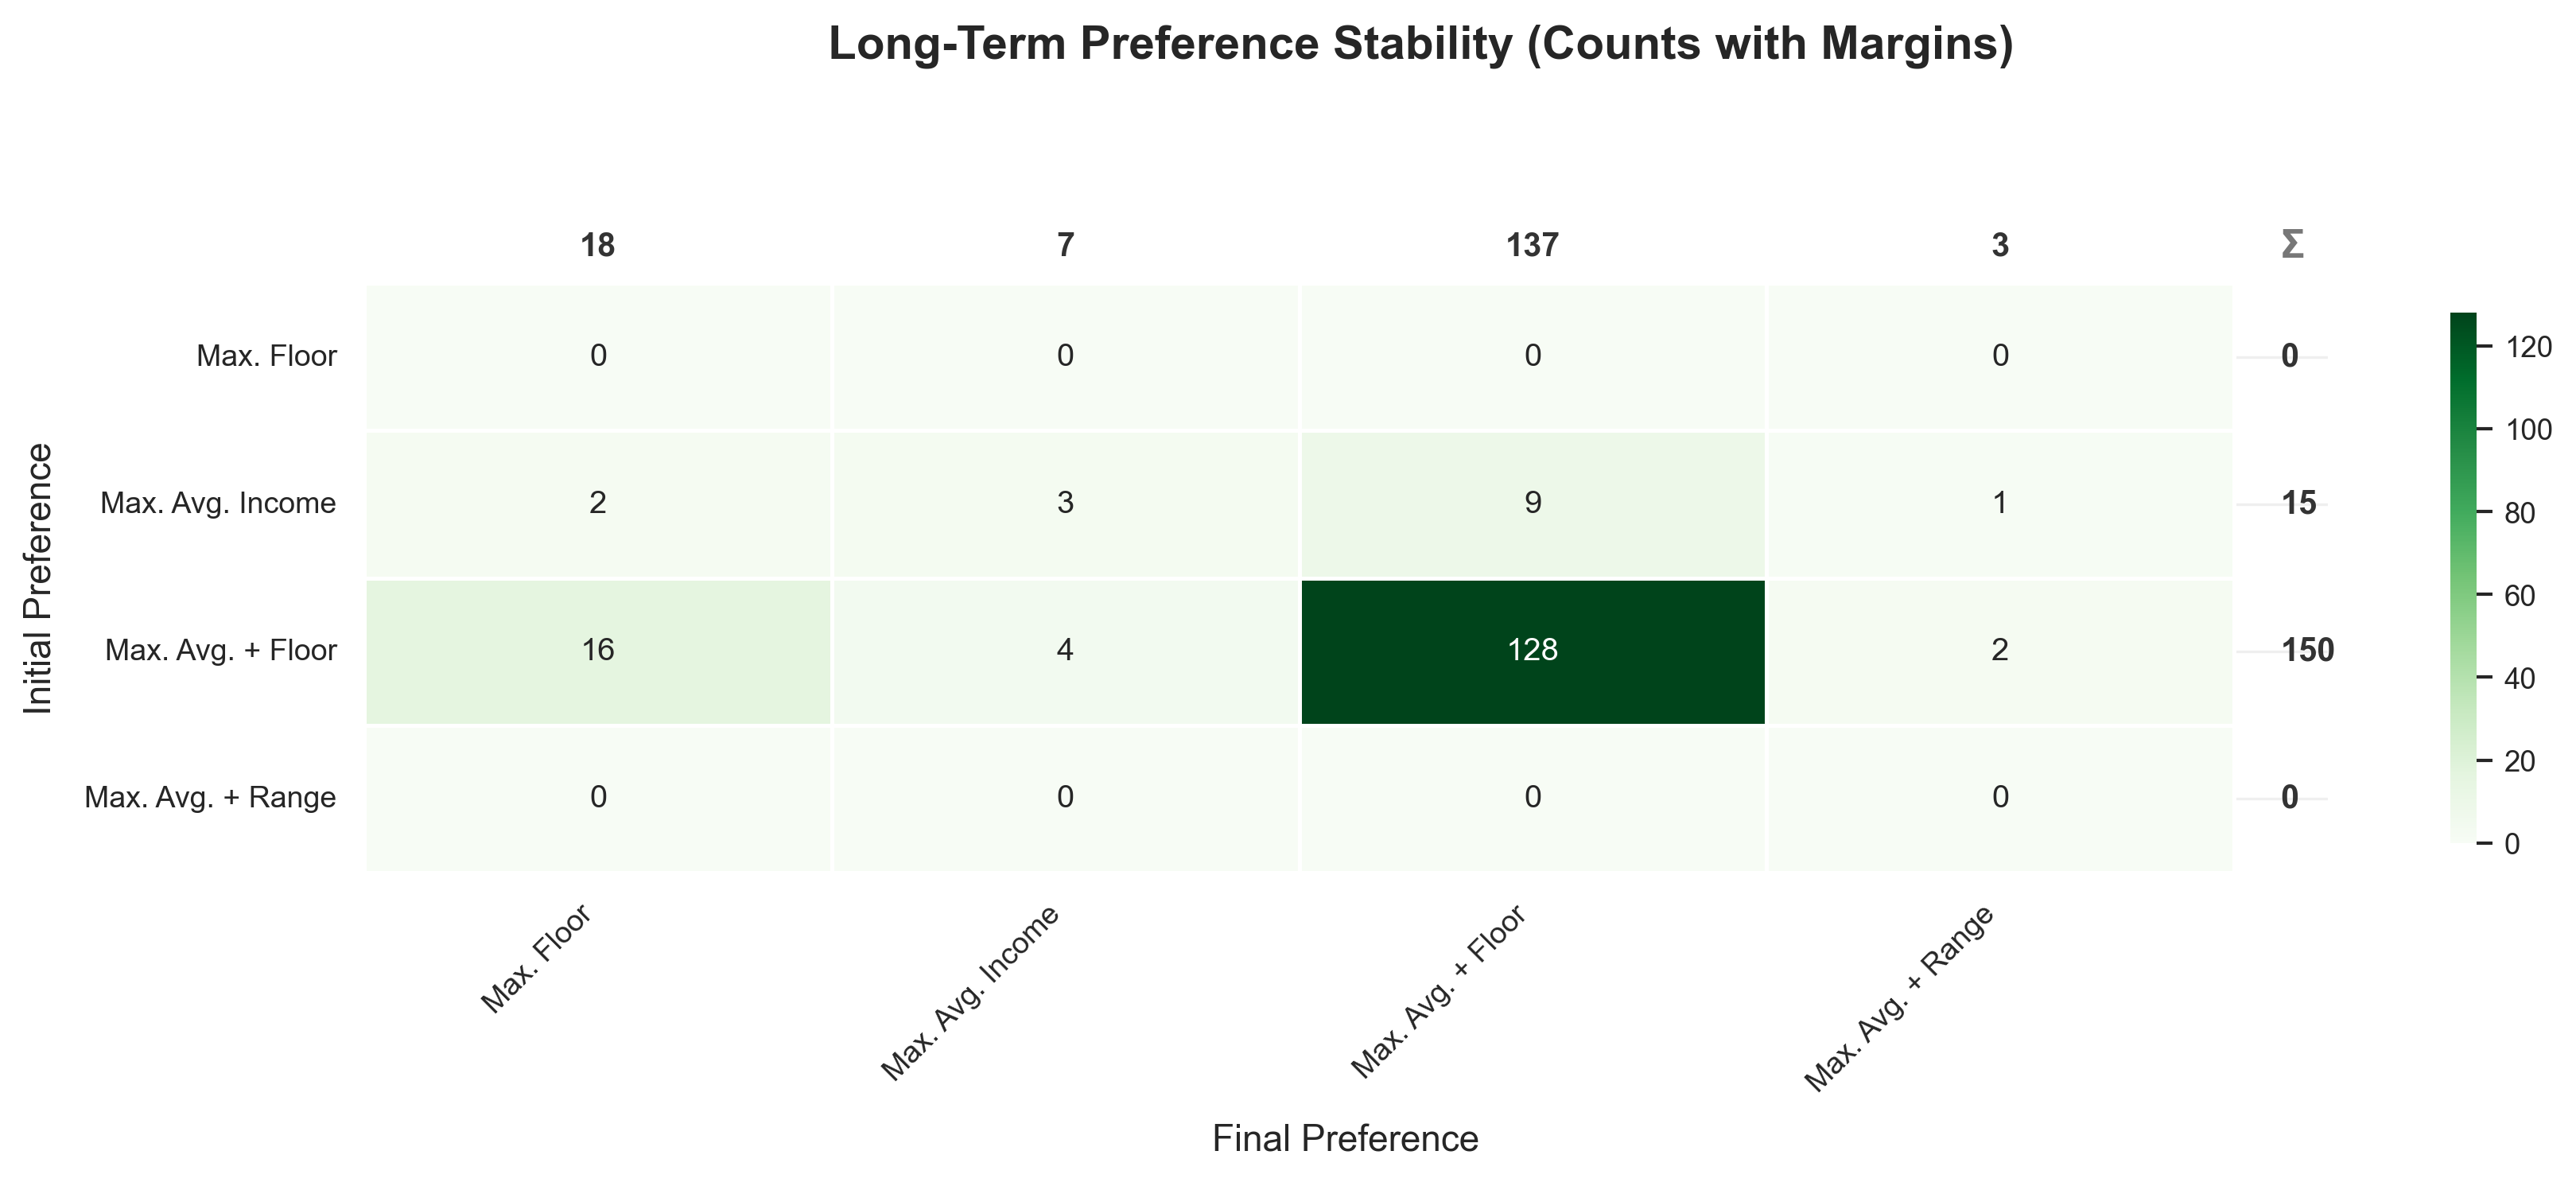

In [12]:
# VISUALIZATION: Long-Term Preference Stability Counts with Margins
principle_order = [
    "Max Floor",
    "Max Avg Income",
    "Max Avg + Floor",
    "Max Avg + Range"
]

principle_display_order = format_principle_labels(principle_order)

# Create the counts heatmap with margins
plot_long_term_margin(
    transition_data,
    principle_display_order=principle_display_order,
    format_principle_label=format_principle_label,
    title_suffix="Main Experiment",
    title="Long-Term Preference Stability (Counts with Margins)"
)


## Switcher Analysis: Income Class and Preference Changes

The following analysis investigates whether agents who changed their top-choice preferences have different income class assignments compared to those who remained loyal to their initial preference.

In [13]:
# Extract income class assignments using centralized function
income_df = extract_income_classes(runs)

print(f"Extracted income data for {len(income_df)} agents")
print(f"\nIncome class distribution:")
income_counts = income_df["income_class"].value_counts().sort_index()
print(income_counts)
print(f"\nPercentages:")
print((income_counts / income_counts.sum() * 100).round(1))

# Show sample
display(income_df.head(15))


Extracted income data for 165 agents

Income class distribution:
income_class
High            7
Low            15
Medium         88
Medium-High    16
Medium-Low     39
Name: count, dtype: int64

Percentages:
income_class
High            4.2
Low             9.1
Medium         53.3
Medium-High     9.7
Medium-Low     23.6
Name: count, dtype: float64


,run_id,agent,income_class_raw,income_class
0,main_experiment_condition_10_config_results,Agent_1,low,Low
1,main_experiment_condition_10_config_results,Agent_2,medium,Medium
2,main_experiment_condition_10_config_results,Agent_3,medium,Medium
3,main_experiment_condition_10_config_results,Agent_4,medium_low,Medium-Low
4,main_experiment_condition_10_config_results,Agent_5,medium,Medium
5,main_experiment_condition_11_config_results,Agent_1,medium_low,Medium-Low
6,main_experiment_condition_11_config_results,Agent_2,medium_low,Medium-Low
7,main_experiment_condition_11_config_results,Agent_3,medium,Medium
8,main_experiment_condition_11_config_results,Agent_4,medium,Medium
9,main_experiment_condition_11_config_results,Agent_5,medium_low,Medium-Low


In [ ]:
# Use centralized function to prepare switcher analysis
switcher_analysis = prepare_switcher_analysis(transition_data, income_df)

# Summary statistics
print("=" * 80)
print("SWITCHER ANALYSIS SUMMARY")
print("=" * 80)
print(f"\nTotal agents analyzed: {len(switcher_analysis)}")
print(f"Agents who switched at ANY point: {switcher_analysis['switched_any'].sum()} ({switcher_analysis['switched_any'].sum()/len(switcher_analysis)*100:.1f}%)")
print(f"Agents who stayed loyal (W1→W4): {(~switcher_analysis['switched_w1_w4']).sum()} ({(~switcher_analysis['switched_w1_w4']).sum()/len(switcher_analysis)*100:.1f}%)")

print("\n\nSwitcher Category Distribution:")
print(switcher_analysis["switcher_category"].value_counts().sort_index())

print("\n\nSwitches by Transition:")
print(f"  W1→W2: {switcher_analysis['switched_w1_w2'].sum()} agents switched")
print(f"  W2→W3: {switcher_analysis['switched_w2_w3'].sum()} agents switched")
print(f"  W3→W4: {switcher_analysis['switched_w3_w4'].sum()} agents switched")

display(switcher_analysis.head(15))

In [ ]:
# Use centralized function to create income comparison summary
switcher_summary, count_long, share_long, composition_percent_long = summarize_income_preferences(switcher_analysis)

# Display the summary table
print("=" * 90)
print("INCOME CLASS DISTRIBUTION BY PREFERENCE STABILITY")
print("=" * 90)
switchers = switcher_analysis[switcher_analysis["switched_any"] == True]
maintainers = switcher_analysis[switcher_analysis["switched_any"] == False]
print(f"Changed preference: {len(switchers)} agents | Maintained preference: {len(maintainers)} agents")
print("=" * 90)
display(switcher_summary)

In [ ]:
# Use centralized visualization function
plot_income_preference_bars(
    switcher_summary,
    count_long,
    share_long,
    title_suffix="Main Experiment"
)

In [ ]:
# Use centralized visualization function
plot_income_composition(
    count_long,
    composition_percent_long,
    title_suffix="Main Experiment"
)